# Module 1: Corporate Project Evaluation & Ranking with ML

## Objective
Build an ML-powered system to rank corporate projects for funding based on:
- **NPV & Cash Flow Forecasting** (Regression)
- **Success Probability Prediction** (Classification)
- **Risk-Adjusted Return Analysis**
- **Executive Explanations** (SHAP)

## Output Deliverables
1. Ranked project list with recommendations (Fund/Review/Hold)
2. SHAP visualizations explaining key drivers
3. Model performance metrics & confidence scores
4. Dashboard-ready JSON/CSV outputs

---

## PHASE 1: Data Preparation & Exploration

In [298]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [299]:
# Load dataset
data_path = '../data/corporate_projects-1.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset shape: (50, 10)

First few rows:
   Project_ID  Department  Investment_Cost  Expected_Cashflow_Year1  \
0           1  Operations           184654                   583556   
1           2   Marketing          2054354                  1447527   
2           3     Finance          2516182                  1372905   
3           4  Operations          3574675                  1817640   
4           5  Operations          2752991                   792139   

   Expected_Cashflow_Year2  Expected_Cashflow_Year3  Historical_ROI  \
0                  2348816                  1888756              $0   
1                   541234                   278576              $0   
2                  1998260                  2312990              $0   
3                   189182                  1434250              $0   
4                  1571101                   111087              $0   

   Market_Growth Project_Risk  Success  
0             $0          Low        0  
1            $-0       

In [300]:
# Data quality checks
print("="*50)
print("DATA QUALITY SUMMARY")
print("="*50)

# Descriptive statistics
print(f"\nDescriptive Statistics:")
print(df.describe())

# Value counts for categorical variables
print(f"\nDepartment Distribution:")
print(df['Department'].value_counts())

print(f"\nRisk Distribution:")
print(df['Project_Risk'].value_counts())

print(f"\nSuccess Distribution (Target Variable):")
print(df['Success'].value_counts())
print(f"Success Rate: {df['Success'].mean()*100:.2f}%")

DATA QUALITY SUMMARY

Descriptive Statistics:
       Project_ID  Investment_Cost  Expected_Cashflow_Year1  \
count         $50              $50                      $50   
mean          $26       $2,508,812               $1,019,832   
std           $15       $1,250,287                 $595,306   
min            $1         $123,247                  $62,666   
25%           $13       $1,731,652                 $532,958   
50%           $26       $2,685,838               $1,037,420   
75%           $38       $3,480,671               $1,475,176   
max           $50       $4,898,669               $1,936,222   

       Expected_Cashflow_Year2  Expected_Cashflow_Year3  Historical_ROI  \
count                      $50                      $50             $50   
mean                $1,245,896               $1,513,842              $0   
std                   $755,861                 $896,571              $0   
min                    $71,959                  $89,353              $0   
25%        

## PHASE 2: Feature Engineering

In [301]:
# Create a copy for feature engineering
df_processed = df.copy()

# 1. Calculate total expected cashflow
cf_cols = ['Expected_Cashflow_Year1', 'Expected_Cashflow_Year2', 'Expected_Cashflow_Year3']
df_processed['Total_Expected_Cashflow'] = df_processed[cf_cols].sum(axis=1)

# 2. Calculate cashflow stability (coefficient of variation)
df_processed['Cashflow_Stability'] = df_processed[cf_cols].std(axis=1) / (df_processed[cf_cols].mean(axis=1) + 1e-6)

# 3. Average annual cashflow
df_processed['Avg_Annual_Cashflow'] = df_processed['Total_Expected_Cashflow'] / 3

# 4. Simple payback period (Investment_Cost / Avg_Annual_Cashflow)
df_processed['Simple_Payback_Period'] = df_processed['Investment_Cost'] / (df_processed['Avg_Annual_Cashflow'] + 1e-6)

# 5. Investment intensity (Investment relative to total cashflow)
df_processed['Investment_Intensity'] = df_processed['Investment_Cost'] / (df_processed['Total_Expected_Cashflow'] + 1e-6)

# 6. Interaction: ROI × Market Growth
df_processed['ROI_Market_Growth_Interaction'] = df_processed['Historical_ROI'] * df_processed['Market_Growth']

# 7. Interaction: Investment × Risk (higher cost + higher risk = more concern)
df_processed['Risk_Encoded'] = df_processed['Project_Risk'].map({'Low': 1, 'Medium': 2, 'High': 3})
df_processed['Investment_Risk_Score'] = df_processed['Investment_Cost'] * df_processed['Risk_Encoded']

# 8. Revenue to cost ratio
df_processed['Revenue_Cost_Ratio'] = df_processed['Total_Expected_Cashflow'] / df_processed['Investment_Cost']# payback ratio

print("✓ Features engineered successfully")
print(f"\nNew features created:")
new_features = ['Total_Expected_Cashflow', 'Cashflow_Stability', 'Avg_Annual_Cashflow', 
                'Simple_Payback_Period', 'Investment_Intensity', 'ROI_Market_Growth_Interaction',
                'Investment_Risk_Score', 'Revenue_Cost_Ratio', 'Risk_Encoded']
print(df_processed[new_features].head())

✓ Features engineered successfully

New features created:
   Total_Expected_Cashflow  Cashflow_Stability  Avg_Annual_Cashflow  \
0                  4821128                  $1           $1,607,043   
1                  2267337                  $1             $755,779   
2                  5684155                  $0           $1,894,718   
3                  3441072                  $1           $1,147,024   
4                  2474327                  $1             $824,776   

   Simple_Payback_Period  Investment_Intensity  ROI_Market_Growth_Interaction  \
0                     $0                    $0                             $0   
1                     $3                    $1                            $-0   
2                     $1                    $0                             $0   
3                     $3                    $1                             $0   
4                     $3                    $1                             $0   

   Investment_Risk_Score  Re

In [302]:
# Calculate NPV (this is what we'll predict in regression)
discount_rate = 0.10  # 10% discount rate

# NPV = CF_Year1/(1+r)^1 + CF_Year2/(1+r)^2 + CF_Year3/(1+r)^3 - Initial_Investment
df_processed['NPV'] = (
    df_processed['Expected_Cashflow_Year1'] / (1 + discount_rate)**1 +
    df_processed['Expected_Cashflow_Year2'] / (1 + discount_rate)**2 +
    df_processed['Expected_Cashflow_Year3'] / (1 + discount_rate)**3 -
    df_processed['Investment_Cost']
)

# Calculate Profitability Index (NPV / Investment_Cost)
df_processed['Profitability_Index'] = df_processed['NPV'] / df_processed['Investment_Cost']

print(f"NPV calculated with discount rate: {discount_rate*100}%")
print(f"\nNPV Statistics:")
print(df_processed['NPV'].describe())
print(f"\nSample NPV values:")
print(df_processed[['Project_ID', 'Investment_Cost', 'Total_Expected_Cashflow', 'NPV', 'Profitability_Index']].head(10))

NPV calculated with discount rate: 10.0%

NPV Statistics:
count           $50
mean       $585,347
std      $1,844,210
min     $-3,809,639
25%       $-679,008
50%        $319,646
75%      $2,025,437
max      $4,281,887
Name: NPV, dtype: float64

Sample NPV values:
   Project_ID  Investment_Cost  Total_Expected_Cashflow        NPV  \
0           1           184654                  4821128 $3,706,072   
1           2          2054354                  2267337   $-81,821   
2           3          2516182                  5684155 $2,121,152   
3           4          3574675                  3441072  $-688,353   
4           5          2752991                  2474327  $-650,973   
5           6          2528388                  2802572  $-252,243   
6           7           628178                  3342402 $2,054,605   
7           8          2763046                  3096211  $-327,587   
8           9          2686644                  4904326 $1,360,695   
9          10          2670406      

## PHASE 3: Preprocessing for ML Models

In [303]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define feature groups
numeric_features = ['Investment_Cost', 'Historical_ROI', 'Market_Growth', 
                    'Total_Expected_Cashflow', 'Cashflow_Stability', 
                    'Avg_Annual_Cashflow', 'Simple_Payback_Period',
                    'Investment_Intensity', 'ROI_Market_Growth_Interaction',
                    'Investment_Risk_Score', 'Revenue_Cost_Ratio']

categorical_features = ['Department', 'Project_Risk']

# Create preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create feature matrix X
X = df_processed[numeric_features + categorical_features].copy()

print(f"Features shape: {X.shape}")
print(f"✓ Preprocessing pipeline created")

Features shape: (50, 13)
✓ Preprocessing pipeline created


## PHASE 4: Regression Module - NPV & Cash Flow Prediction

In [304]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Target variable for regression
y_reg = df_processed['NPV'].copy()

# Train-test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train_reg.shape[0]}")
print(f"Test set size: {X_test_reg.shape[0]}")

Training set size: 40
Test set size: 10


In [305]:
# Build Random Forest Regression Pipeline
rf_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

# Train model
print("Training Random Forest Regressor...")
rf_reg_pipeline.fit(X_train_reg, y_train_reg)

# Predictions
y_pred_reg_train = rf_reg_pipeline.predict(X_train_reg)
y_pred_reg_test = rf_reg_pipeline.predict(X_test_reg)

# Evaluate
train_r2 = r2_score(y_train_reg, y_pred_reg_train)
test_r2 = r2_score(y_test_reg, y_pred_reg_test)
train_mae = mean_absolute_error(y_train_reg, y_pred_reg_train)
test_mae = mean_absolute_error(y_test_reg, y_pred_reg_test)
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_pred_reg_train))
test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_test))

print("\n" + "="*50)
print("REGRESSION MODEL PERFORMANCE")
print("="*50)
print(f"\nTraining R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"\nTraining MAE: ${train_mae:,.0f}")
print(f"Test MAE: ${test_mae:,.0f}")
print(f"\nTraining RMSE: ${train_rmse:,.0f}")
print(f"Test RMSE: ${test_rmse:,.0f}")

Training Random Forest Regressor...

REGRESSION MODEL PERFORMANCE

Training R²: 0.9775
Test R²: 0.9453

Training MAE: $168,154
Test MAE: $306,157

Training RMSE: $262,674
Test RMSE: $477,054


In [306]:
# Cross-validation for robustness
cv_folds = 5
cv_scores = cross_val_score(rf_reg_pipeline, X, y_reg, cv=cv_folds, scoring='r2')

print(f"\nCross-Validation (k={cv_folds} folds):")
print(f"CV R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Cross-Validation (k=5 folds):
CV R² Scores: [0.90912152 0.96501619 0.85005318 0.90289231 0.89877288]
Mean CV R²: 0.9052 (+/- 0.0366)



Top 10 Features for NPV Prediction:
Revenue_Cost_Ratio              $1
Simple_Payback_Period           $0
Investment_Intensity            $0
Investment_Cost                 $0
Total_Expected_Cashflow         $0
Investment_Risk_Score           $0
Avg_Annual_Cashflow             $0
Historical_ROI                  $0
Cashflow_Stability              $0
ROI_Market_Growth_Interaction   $0
dtype: float64


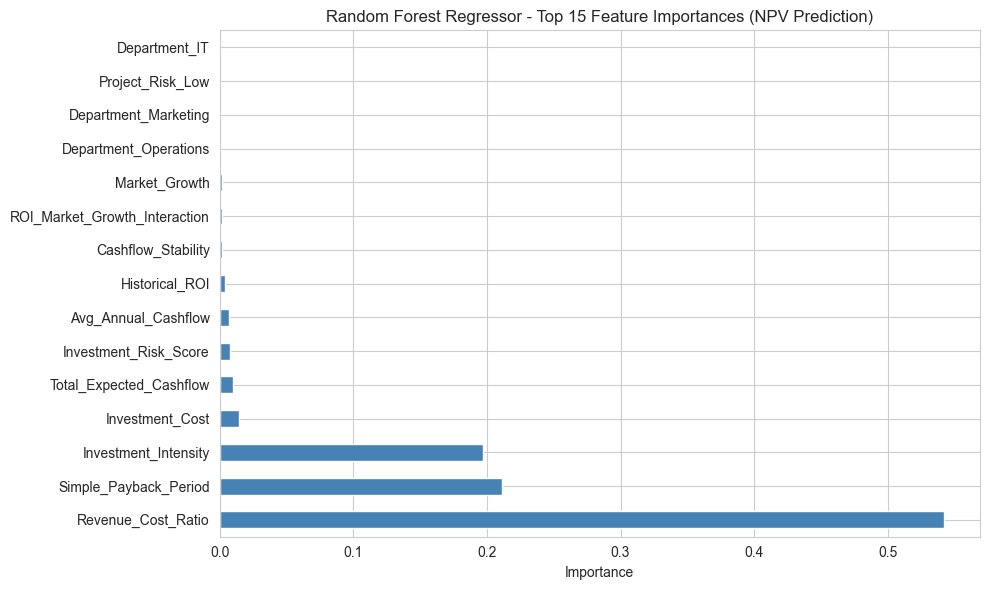

In [307]:
# Feature importance for regression
reg_model = rf_reg_pipeline.named_steps['regressor']
feature_names_reg = (numeric_features + 
                     list(rf_reg_pipeline.named_steps['preprocessor']
                         .named_transformers_['cat']
                         .named_steps['onehot']
                         .get_feature_names_out(categorical_features)))

importances_reg = pd.Series(
    reg_model.feature_importances_,
    index=feature_names_reg
).sort_values(ascending=False)

# Plot top 15 features
fig, ax = plt.subplots(figsize=(10, 6))
importances_reg.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Random Forest Regressor - Top 15 Feature Importances (NPV Prediction)')
plt.tight_layout()
print("\nTop 10 Features for NPV Prediction:")
print(importances_reg.head(10))

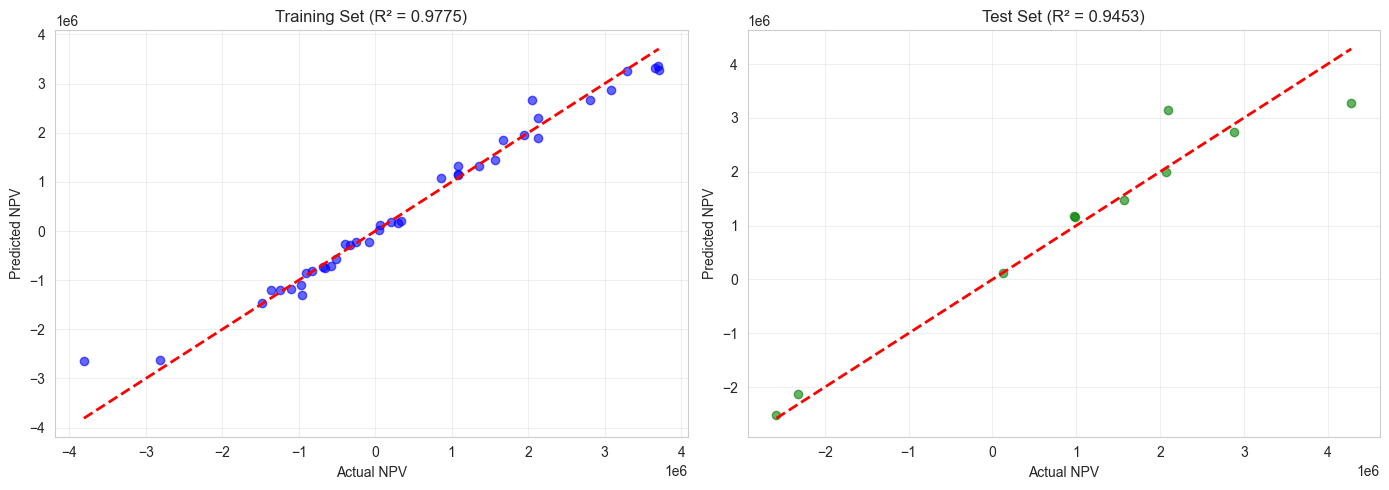

In [308]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(y_train_reg, y_pred_reg_train, alpha=0.6, color='blue')
axes[0].plot([y_train_reg.min(), y_train_reg.max()], [y_train_reg.min(), y_train_reg.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual NPV')
axes[0].set_ylabel('Predicted NPV')
axes[0].set_title(f'Training Set (R² = {train_r2:.4f})')
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test_reg, y_pred_reg_test, alpha=0.6, color='green')
axes[1].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual NPV')
axes[1].set_ylabel('Predicted NPV')
axes[1].set_title(f'Test Set (R² = {test_r2:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## PHASE 5: Classification Module - Success Probability Prediction

In [309]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Target variable for classification
y_clf = df_processed['Success'].copy()

# Stratified train-test split (maintains class distribution)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Training set size: {X_train_clf.shape[0]}")
print(f"Test set size: {X_test_clf.shape[0]}")
print(f"\nTraining set success rate: {y_train_clf.mean()*100:.2f}%")
print(f"Test set success rate: {y_test_clf.mean()*100:.2f}%")

Training set size: 40
Test set size: 10

Training set success rate: 52.50%
Test set success rate: 50.00%


In [310]:
# Build Random Forest Classification Pipeline
rf_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'  # Handle class imbalance
    ))
])

# Train model
print("Training Random Forest Classifier...")
rf_clf_pipeline.fit(X_train_clf, y_train_clf)

# Predictions and probabilities
y_pred_clf_train = rf_clf_pipeline.predict(X_train_clf)
y_pred_clf_test = rf_clf_pipeline.predict(X_test_clf)
y_prob_clf_train = rf_clf_pipeline.predict_proba(X_train_clf)[:, 1]
y_prob_clf_test = rf_clf_pipeline.predict_proba(X_test_clf)[:, 1]

# Evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n" + "="*50)
print("CLASSIFICATION MODEL PERFORMANCE (TEST SET)")
print("="*50)
print(f"\nAccuracy: {accuracy_score(y_test_clf, y_pred_clf_test):.4f}")
print(f"Precision: {precision_score(y_test_clf, y_pred_clf_test):.4f}")
print(f"Recall: {recall_score(y_test_clf, y_pred_clf_test):.4f}")
print(f"F1-Score: {f1_score(y_test_clf, y_pred_clf_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_clf, y_prob_clf_test):.4f}")

print(f"\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test_clf, y_pred_clf_test, target_names=['Failed', 'Success']))

Training Random Forest Classifier...

CLASSIFICATION MODEL PERFORMANCE (TEST SET)

Accuracy: 0.4000
Precision: 0.3333
Recall: 0.2000
F1-Score: 0.2500
ROC-AUC: 0.6000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Failed       0.43      0.60      0.50         5
     Success       0.33      0.20      0.25         5

    accuracy                           0.40        10
   macro avg       0.38      0.40      0.38        10
weighted avg       0.38      0.40      0.38        10



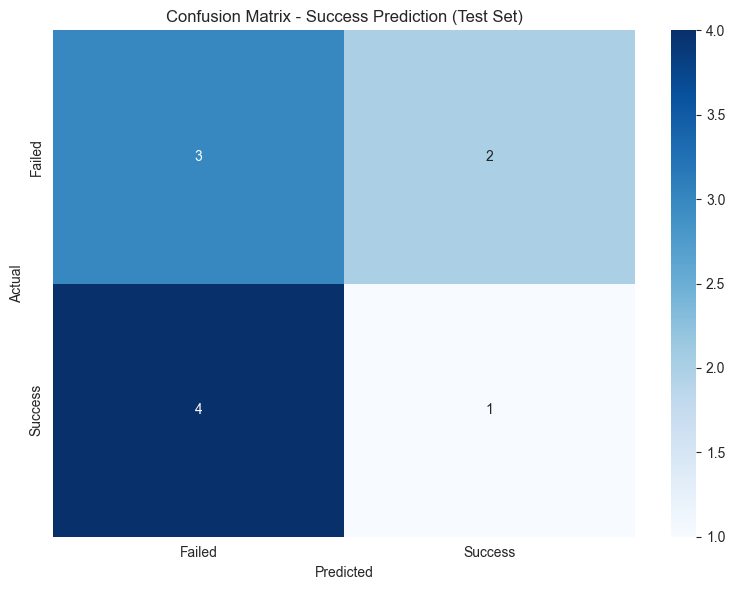

In [311]:
# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf_test)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['Failed', 'Success'], yticklabels=['Failed', 'Success'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Success Prediction (Test Set)')
plt.tight_layout()

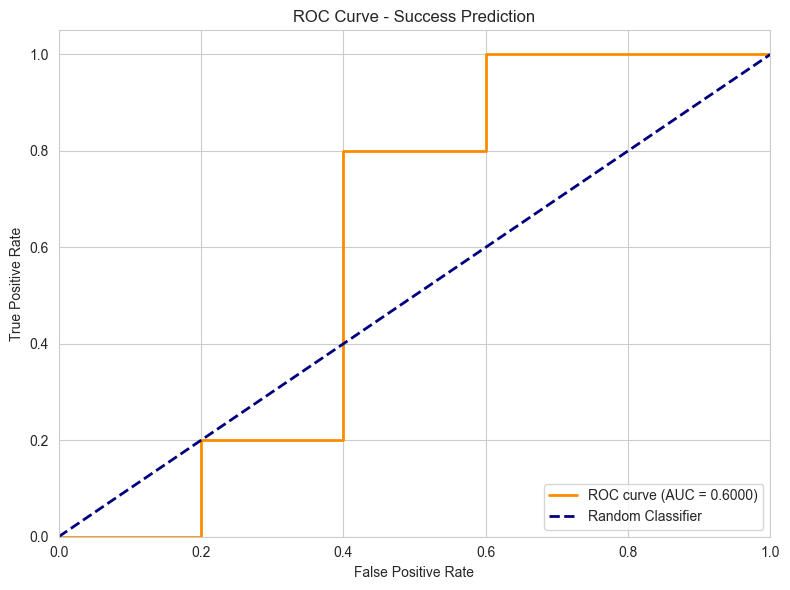

In [312]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob_clf_test)
roc_auc = roc_auc_score(y_test_clf, y_prob_clf_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Success Prediction')
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


Top 10 Features for Success Prediction:
Cashflow_Stability              $0
Historical_ROI                  $0
ROI_Market_Growth_Interaction   $0
Investment_Risk_Score           $0
Investment_Intensity            $0
Simple_Payback_Period           $0
Total_Expected_Cashflow         $0
Investment_Cost                 $0
Revenue_Cost_Ratio              $0
Avg_Annual_Cashflow             $0
dtype: float64


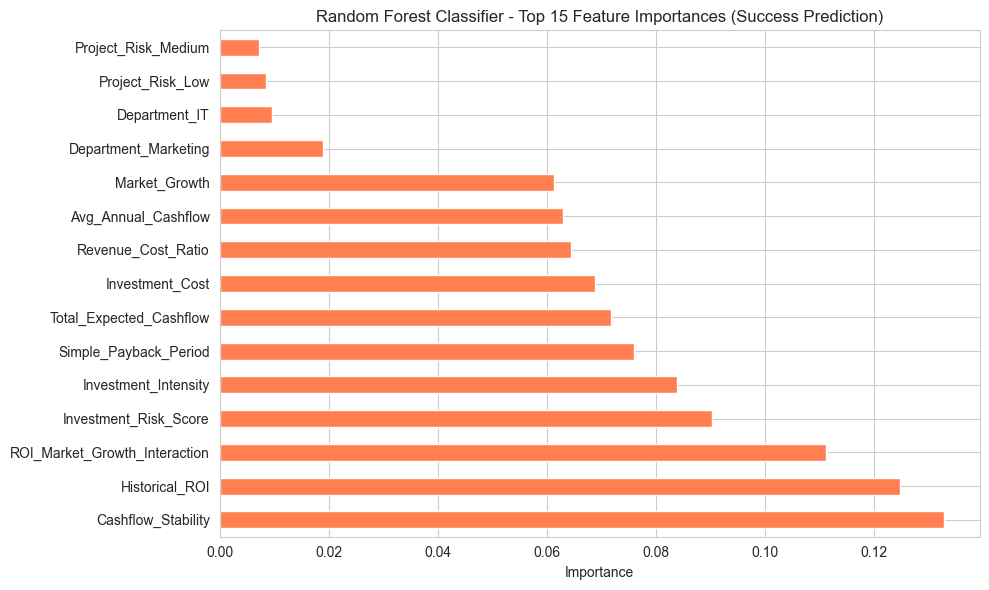

In [313]:
# Feature importance for classification
clf_model = rf_clf_pipeline.named_steps['classifier']

importances_clf = pd.Series(
    clf_model.feature_importances_,
    index=feature_names_reg
).sort_values(ascending=False)

# Plot top 15 features
fig, ax = plt.subplots(figsize=(10, 6))
importances_clf.head(15).plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Importance')
ax.set_title('Random Forest Classifier - Top 15 Feature Importances (Success Prediction)')
plt.tight_layout()

print("\nTop 10 Features for Success Prediction:")
print(importances_clf.head(10))

## PHASE 6: Generate Predictions for All Projects

In [314]:
# Generate NPV predictions for all projects
npv_predictions = rf_reg_pipeline.predict(X)

# Generate success probability for all projects
success_probabilities = rf_clf_pipeline.predict_proba(X)[:, 1]

# Add predictions to dataframe
df_processed['Predicted_NPV'] = npv_predictions
df_processed['Predicted_Success_Probability'] = success_probabilities

print("✓ Predictions generated for all projects")
print(f"\nPredicted NPV Statistics:")
print(df_processed['Predicted_NPV'].describe())
print(f"\nPredicted Success Probability Statistics:")
print(df_processed['Predicted_Success_Probability'].describe())

✓ Predictions generated for all projects

Predicted NPV Statistics:
count           $50
mean       $501,300
std      $1,434,750
min     $-2,652,401
25%       $-533,484
50%        $201,132
75%      $1,571,548
max      $2,626,679
Name: Predicted_NPV, dtype: float64

Predicted Success Probability Statistics:
count   $50
mean     $0
std      $0
min      $0
25%      $0
50%      $0
75%      $1
max      $1
Name: Predicted_Success_Probability, dtype: float64


In [315]:
# Display NPV values in readable format (without scientific notation)
pd.set_option('display.float_format', lambda x: f'${x:,.0f}')

print("NPV VALUES IN READABLE FORMAT:")
print("="*70)
print(df_processed[['Project_ID', 'NPV', 'Predicted_NPV', 'Expected_Value']].head(20))

# Reset to default format if needed later
pd.reset_option('display.float_format')

NPV VALUES IN READABLE FORMAT:


KeyError: "['Expected_Value'] not in index"

## PHASE 7: Risk-Adjusted Ranking & Economic Value Calculation

In [ ]:
# Calculate risk-adjusted metrics

# 1. Expected Value = NPV × Success_Probability
df_processed['Expected_Value'] = df_processed['Predicted_NPV'] * df_processed['Predicted_Success_Probability']

# 3. Return on Investment Index = Predicted_NPV / Investment_Cost
df_processed['ROI_Index'] = df_processed['Predicted_NPV'] / df_processed['Investment_Cost']

# 4. Risk Score (inverse of success probability × risk level)
df_processed['Risk_Score'] = (1 - df_processed['Predicted_Success_Probability']) * df_processed['Risk_Encoded']
#  ==========================================
# STEP 1: Create Capital Efficiency Metric
# ==========================================
# 2. Risk-Adjusted Return = Expected_Value / Investment_Cost # redundant and should not be used for ranking

df_processed['Risk_Adjusted_Return'] = (
    df_processed['Expected_Value'] /
    df_processed['Investment_Cost']
)

# Optional: avoid infinite values
df_processed['Risk_Adjusted_Return'] = df_processed['Risk_Adjusted_Return'].replace([np.inf, -np.inf], 0)

# ==========================================
# STEP 2: Normalize Metrics (0-1 Percentiles)
# ==========================================

df_processed['EV_Percentile'] = df_processed['Expected_Value'].rank(pct=True)

df_processed['Success_Percentile'] = (
    df_processed['Predicted_Success_Probability'].rank(pct=True)
)

df_processed['RAR_Percentile'] = (
    df_processed['Risk_Adjusted_Return'].rank(pct=True)
)

df_processed['ROI_Percentile'] = (
    df_processed['Historical_ROI'].rank(pct=True)
)

# LOWER risk = BETTER
df_processed['Risk_Percentile'] = (
    1 - df_processed['Risk_Score'].rank(pct=True)
)
df_processed['Risk_Adjusted_EV'] = (
    df_processed['Expected_Value'] /
    df_processed['Risk_Score']
)
df_processed['RAEV_Percentile'] = (
    df_processed['Risk_Adjusted_EV'].rank(pct=True)
)
# ==========================================
# STEP 3: Executive Priority Score
# ==========================================

df_processed['Priority_Score'] = (
    0.30 * df_processed['EV_Percentile'] +
    0.20 * df_processed['Success_Percentile'] +
    0.25 * df_processed['RAR_Percentile'] +
    0.10 * df_processed['ROI_Percentile'] +
    0.15 * df_processed['RAEV_Percentile']
)

# ==========================================
# STEP 4: Executive Penalty Rules
# ==========================================
# High risk penalty
df_processed.loc[
    df_processed['Risk_Score'] > 5,
    'Priority_Score'
] *= 0.85

# Low probability penalty
df_processed.loc[
    df_processed['Predicted_Success_Probability'] < 0.40,
    'Priority_Score'
] *= 0.90

# Negative NPV penalty
df_processed.loc[
    df_processed['NPV'] < 0,
    'Priority_Score'
] *= 0.50

# Negative EV penalty
df_processed.loc[
    df_processed['Expected_Value'] < 0,
    'Priority_Score'
] *= 0.50

# ================================
# STEP 5: Rank Projects by Priority Score
# ================================


def generate_recommendation(row):

    if (
        row['Expected_Value'] > 0 and
        row['NPV'] > 0 and
        row['Risk_Score'] <= 4 and
        row['Predicted_Success_Probability'] >= 0.60
    ):
        return 'Fund'

    elif (
        row['Expected_Value'] < 0 or
        row['NPV'] < 0
    ):
        return 'Reject'

    else:
        return 'Review'


df_processed['Recommendation'] = (
    df_processed.apply(generate_recommendation, axis=1)
)

recommendation_map = {
    'Fund': 1,
    'Review': 2,
    'Reject': 3
}

df_processed['Recommendation_Score'] = df_processed['Recommendation'].map(recommendation_map)

# Rank all projects by Recommendation_Score (ascending: 1=Fund, 2=Review, 3=Reject), then Priority_Score
df_ranked = df_processed.sort_values(
    by=['Recommendation_Score', 'Priority_Score'],
    ascending=[True, False]  # Fund first (1), then by Priority Score descending
).reset_index(drop=True)

# Add Rank column - each project gets a unique sequential rank
df_ranked['Rank'] = range(1, len(df_ranked) + 1)

# Verify unique ranks
print("\n✓ Projects Ranked with Unique Sequential Ranks")
print(f"  Total Projects Ranked: {len(df_ranked)}")
print(f"  Rank Range: {df_ranked['Rank'].min()} to {df_ranked['Rank'].max()}")
print(f"  Unique Ranks: {df_ranked['Rank'].nunique()}")


    Project_ID  Department  Investment_Cost  Expected_Cashflow_Year1  \
0           43          IT           664685                   963910   
1           42  Operations          2685031                   401279   
2           25   Marketing          1970928                  1787095   
3           13  Operations          3485357                  1475472   
4            3     Finance          2516182                  1372905   
5           36     Finance          2758505                  1383382   
6            9  Operations          2686644                  1335160   
7           35          IT           296769                  1806187   
8           28          IT          1873415                  1227888   
9           45   Marketing          1411736                  1700237   
10          18   Marketing          2845683                  1554384   
11          49          IT           123247                  1371685   
12          40  Operations          3147262                  147

Metric	Correlation
Market_Growth vs Predicted_NPV	-0.180
is not ideal, but it is also not necessarily wrong.
Interpretation:
-0.18 = weak negative relationship
practically close to zero
your model is saying:
higher market growth does NOT strongly increase NPV

In [ ]:
display_cols = [ 
'Project_ID'                    ,
'Department'                    ,
'Investment_Cost'               ,
'Expected_Cashflow_Year1'       ,
'Expected_Cashflow_Year2'       ,
'Expected_Cashflow_Year3'       ,
'Historical_ROI'                ,
'Market_Growth'                 ,
'Project_Risk'                  ,
'NPV'                           ,
'Profitability_Index'           ,
'Simple_Payback_Period'         ,
'Capital_Efficiency'            ,
'Risk_Adjusted_Return'          ,
'Predicted_NPV'                 ,
'Predicted_Success_Probability' ,
'Expected_Value'                ,
'Priority_Score'                   ,
'Recommendation'                ,
# 'Review_Priority'               ,
'Rank' 
]

df_display = df_ranked[display_cols].copy()

# Format numeric fields for readability
for col in ['NPV', 'Predicted_NPV','Expected_Cashflow_Year3', 'Expected_Value','Investment_Cost','Risk_Adjusted_Return']:
    df_display[col] = df_display[col].apply(lambda x: f'${x:,.0f}')

df_display['Historical_ROI'] = df_display['Historical_ROI'].apply(lambda x: f'{x:.2%}')
df_display['Predicted_Success_Probability'] = df_display['Predicted_Success_Probability'].apply(lambda x: f'{x:.1%}')
# df_display['Risk_Score'] = df_display['Risk_Score'].apply(lambda x: f'{x:.2f}')

print(df_display.to_string(index=False))

# Save to CSV
df_display.to_csv('../outputs/module1_ranked_projects.csv', index=False)
print("✓ Saved: module1_ranked_projects.csv")

 Project_ID Department Investment_Cost  Expected_Cashflow_Year1  Expected_Cashflow_Year2 Expected_Cashflow_Year3 Historical_ROI  Market_Growth Project_Risk         NPV  Profitability_Index  Simple_Payback_Period  Capital_Efficiency Risk_Adjusted_Return Predicted_NPV Predicted_Success_Probability Expected_Value  Priority_Score Recommendation  Rank
         43         IT        $664,685                   963910                  2285000              $2,068,163         24.00%           0.14       Medium  $3,653,868             5.497142               0.375029            2.502193                   $3    $2,533,058                         65.7%     $1,663,170        0.889000           Fund     1
          3    Finance      $2,516,182                  1372905                  1998260              $2,312,990         19.00%           0.02         High  $2,121,152             0.843004               1.327998            0.521339                   $1    $1,545,149                         84.9%     $

## PHASE 9: Export Results

In [ ]:
# Export model performance metrics & ranking configuration
metrics = {
    'Regression_Model': {
        'Test_R2': test_r2,
        'Test_MAE': test_mae,
        'Test_RMSE': test_rmse,
        'Train_R2': train_r2,
        'Train_MAE': train_mae,
        'Train_RMSE': train_rmse,
        'CV_Mean_R2': cv_scores.mean(),
        'CV_Std_R2': cv_scores.std()
    },
    'Classification_Model': {
        'Test_Accuracy': accuracy_score(y_test_clf, y_pred_clf_test),
        'Test_Precision': precision_score(y_test_clf, y_pred_clf_test),
        'Test_Recall': recall_score(y_test_clf, y_pred_clf_test),
        'Test_F1': f1_score(y_test_clf, y_pred_clf_test),
        'Test_ROC_AUC': roc_auc_score(y_test_clf, y_prob_clf_test)
    },
    'Ranking_Logic': {
        'System': '3-Pillar (EV + RAR - Risk)',
        'Hold_Filters': {
            'Max_Negative_EV': 0,
            'Min_Success_Probability': 0.35,
            'Max_Risk_Score': 1.5
        },
        'Fund_Criteria': {
            'Min_EV_Percentile': 0.75,
            'Min_Success_Probability': 0.60,
            'Max_Risk_Score': 'median'
        },
        'Priority_Score_Formula': '0.60×EV_Percentile + 0.25×RAR_Percentile - 0.15×Risk_Percentile'
    },
    'Financial_Assumptions': {
        'Discount_Rate': discount_rate,
        'NPV_Calculation': 'Discounted 3-year cash flows'
    }
}

import json

# Display metrics
print("\n" + "="*50)
print("MODEL METRICS & RANKING CONFIGURATION")
print("="*50)
print(json.dumps(metrics, indent=2))

✓ Saved: module1_model_metrics.json

MODEL METRICS SUMMARY
{
  "Regression_Model": {
    "Test_R2": 0.9453124134287854,
    "Test_MAE": 306156.7697761447,
    "Test_RMSE": 477054.4824255373,
    "Train_R2": 0.9775197928229117,
    "Train_MAE": 168153.90107256075,
    "Train_RMSE": 262674.47754024056,
    "CV_Mean_R2": 0.9051712170219981,
    "CV_Std_R2": 0.036554497941757726
  },
  "Classification_Model": {
    "Test_Accuracy": 0.4,
    "Test_Precision": 0.3333333333333333,
    "Test_Recall": 0.2,
    "Test_F1": 0.25,
    "Test_ROC_AUC": 0.6
  },
  "Thresholds": {
    "Fund_Threshold": 0.65,
    "Review_Threshold": 0.55,
    "Discount_Rate": 0.1
  },
  "Ranking_Weights": {
    "Expected_Value": 0.4,
    "Success_Probability": 0.3,
    "Risk_Adjusted_Return": 0.2,
    "Revenue_Cost_Ratio": 0.1
  }
}


## PHASE 10: SHAP Analysis for Explainability

In [ ]:
# Install SHAP if not already installed
import subprocess
import sys

try:
    import shap
    print("✓ SHAP already installed")
except ImportError:
    print("Installing SHAP...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap
    print("✓ SHAP installed")

✓ SHAP already installed


In [ ]:
import shap

# Prepare data for SHAP (use preprocessed features)
X_processed = rf_reg_pipeline.named_steps['preprocessor'].transform(X)

# Create SHAP explainer for regression model
print("Creating SHAP explainer for Regression model...")
reg_model_final = rf_reg_pipeline.named_steps['regressor']
explainer_reg = shap.TreeExplainer(reg_model_final)
shap_values_reg = explainer_reg.shap_values(X_processed)

print("✓ SHAP explainer created for Regression")
print(f"SHAP values shape: {shap_values_reg.shape}")

Creating SHAP explainer for Regression model...
✓ SHAP explainer created for Regression
SHAP values shape: (50, 16)


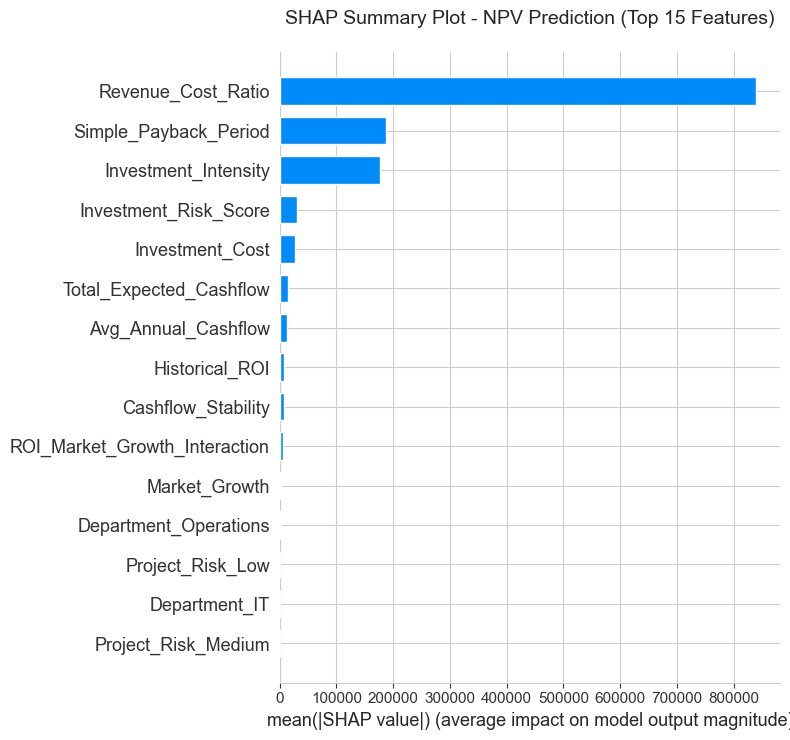

✓ Saved: shap_summary_regression.png


In [ ]:
# SHAP Summary Plot for Regression (top NPV projects)
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values_reg, X_processed, feature_names=feature_names_reg, 
                  plot_type='bar', max_display=15, show=False)
plt.title('SHAP Summary Plot - NPV Prediction (Top 15 Features)', fontsize=14, pad=20)
plt.tight_layout()

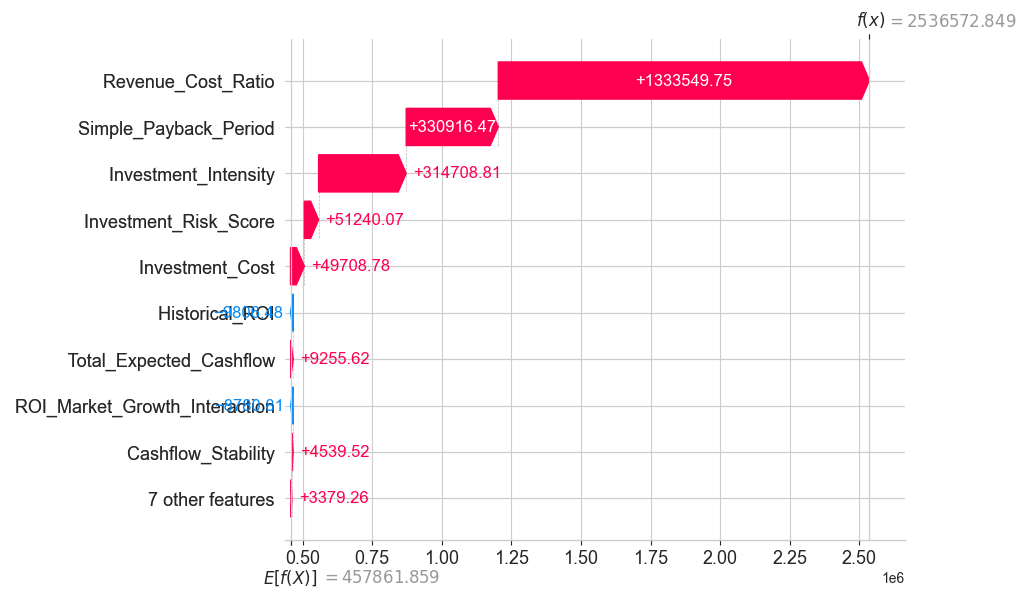

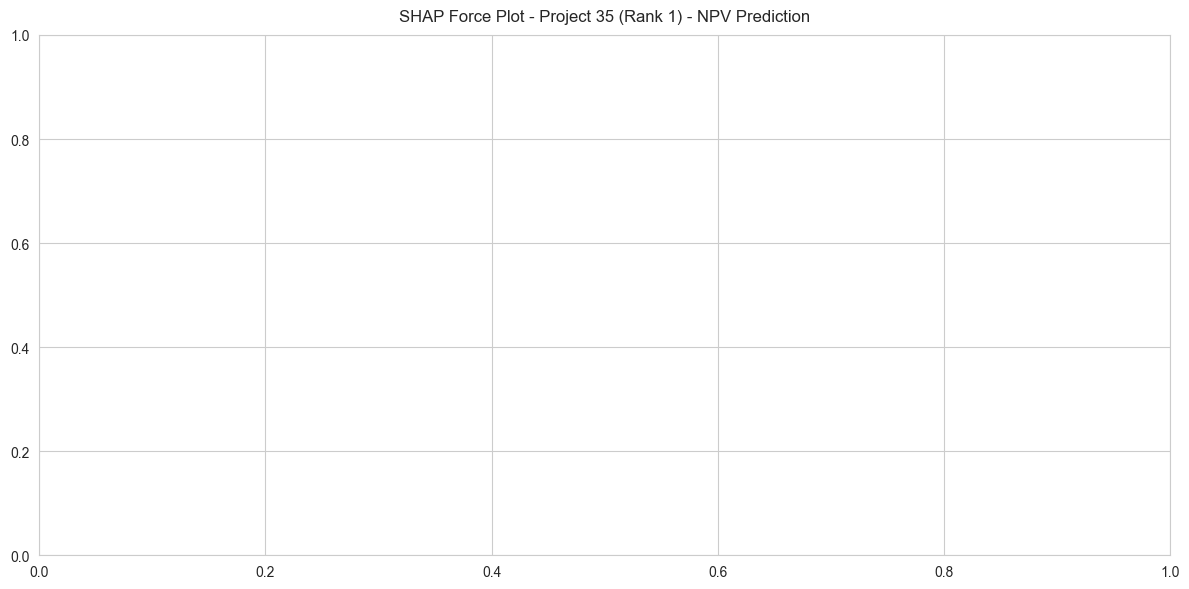

✓ Saved: shap_force_regression_rank_1.png


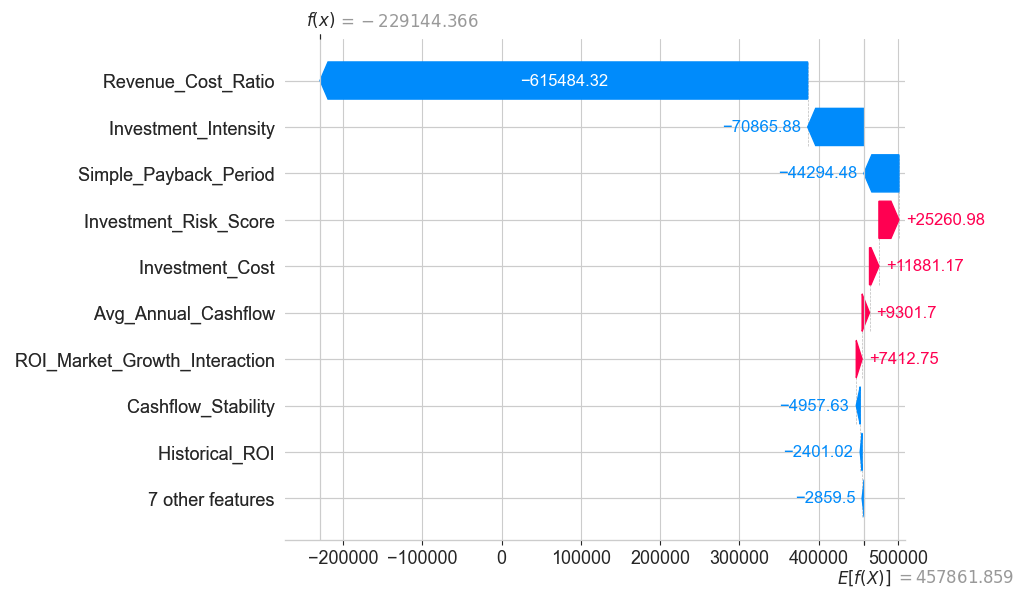

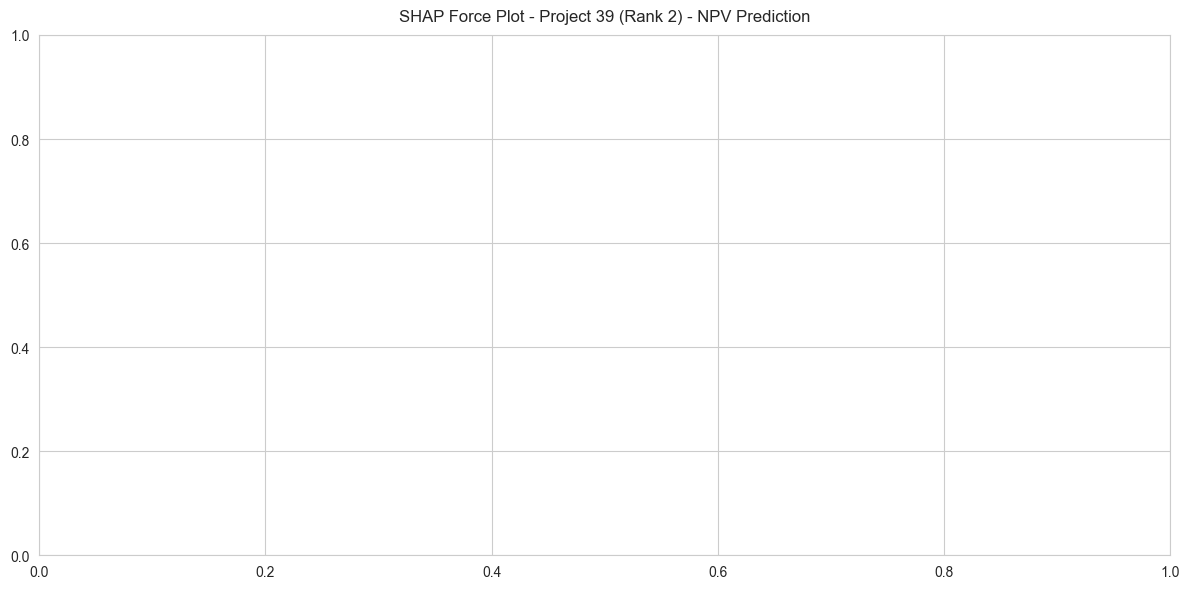

✓ Saved: shap_force_regression_rank_2.png


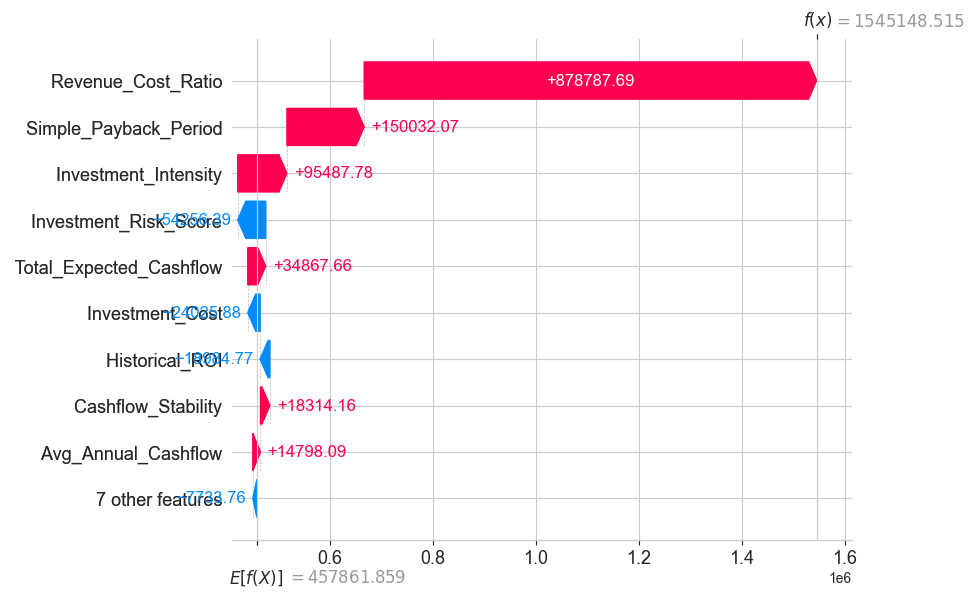

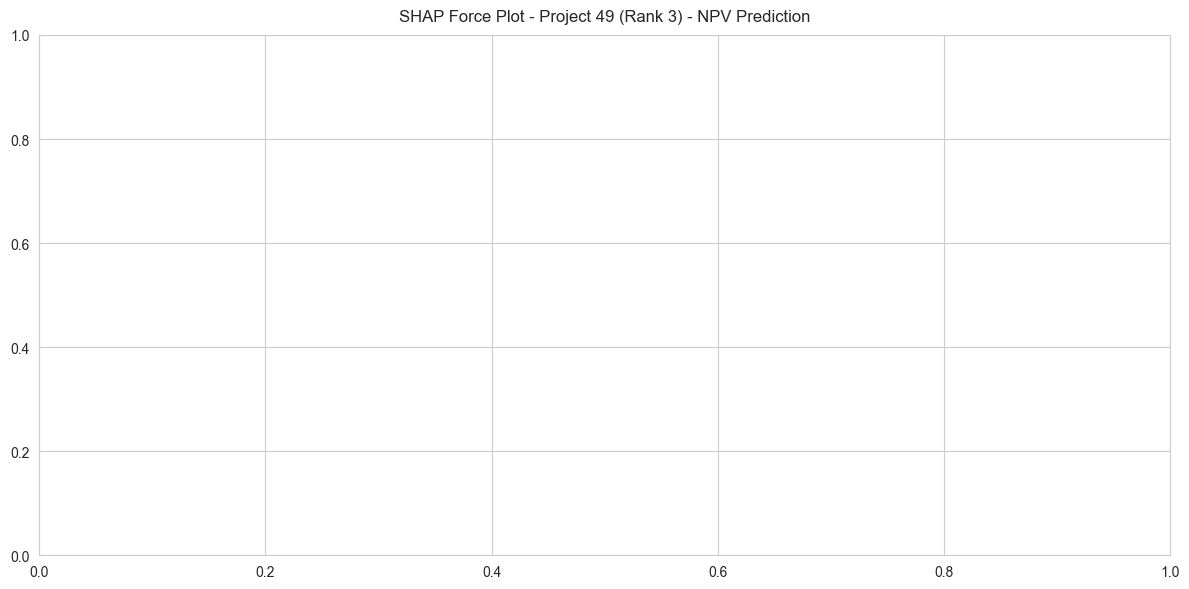

✓ Saved: shap_force_regression_rank_3.png


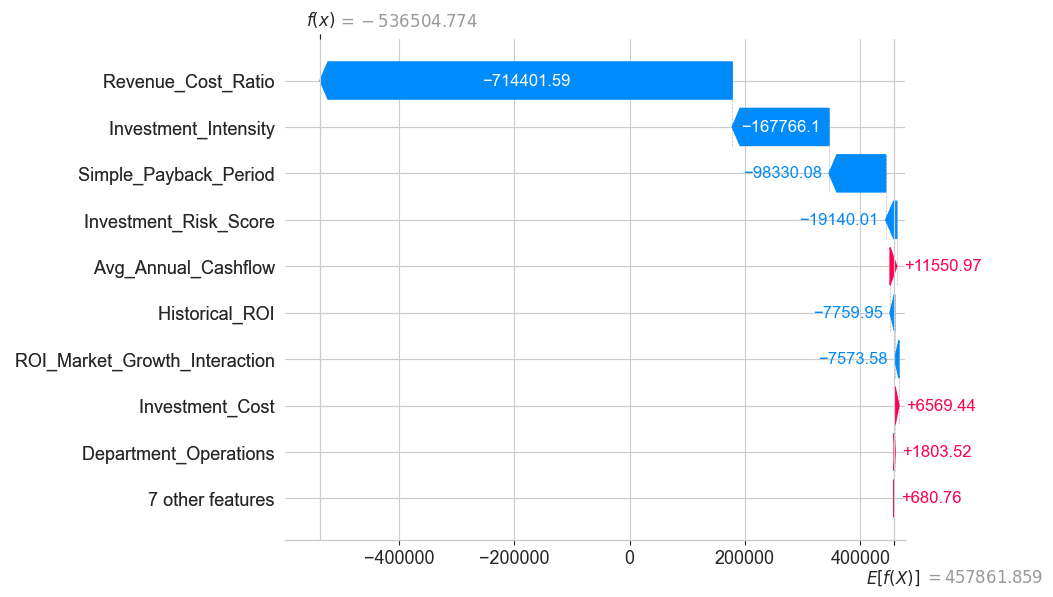

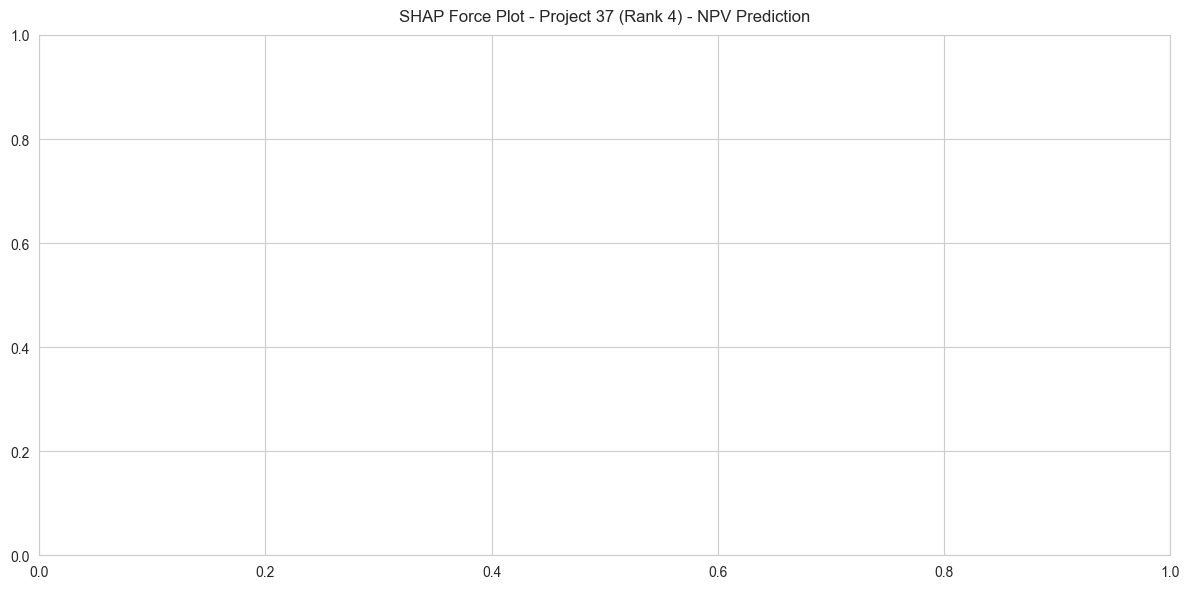

✓ Saved: shap_force_regression_rank_4.png


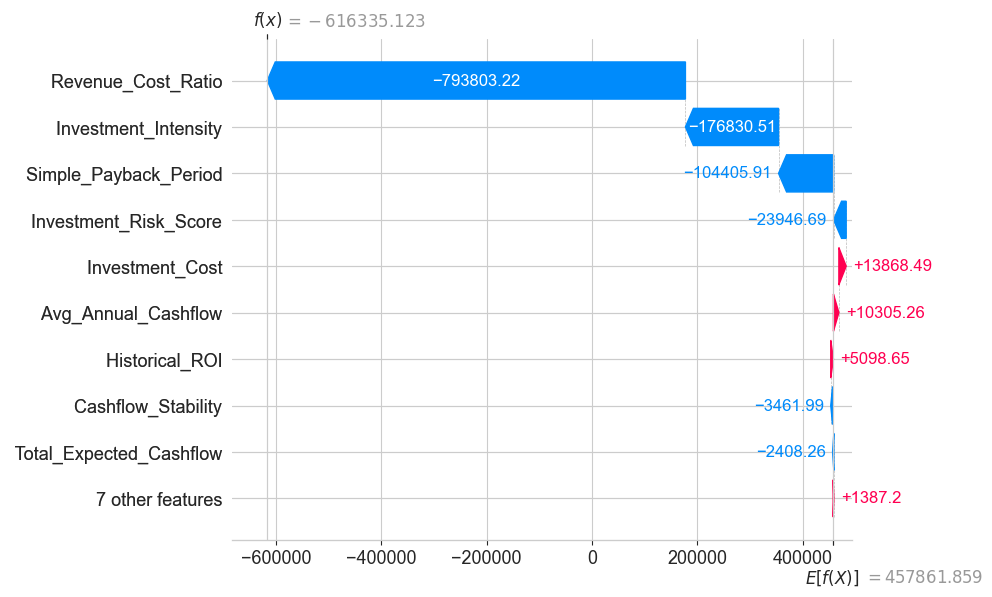

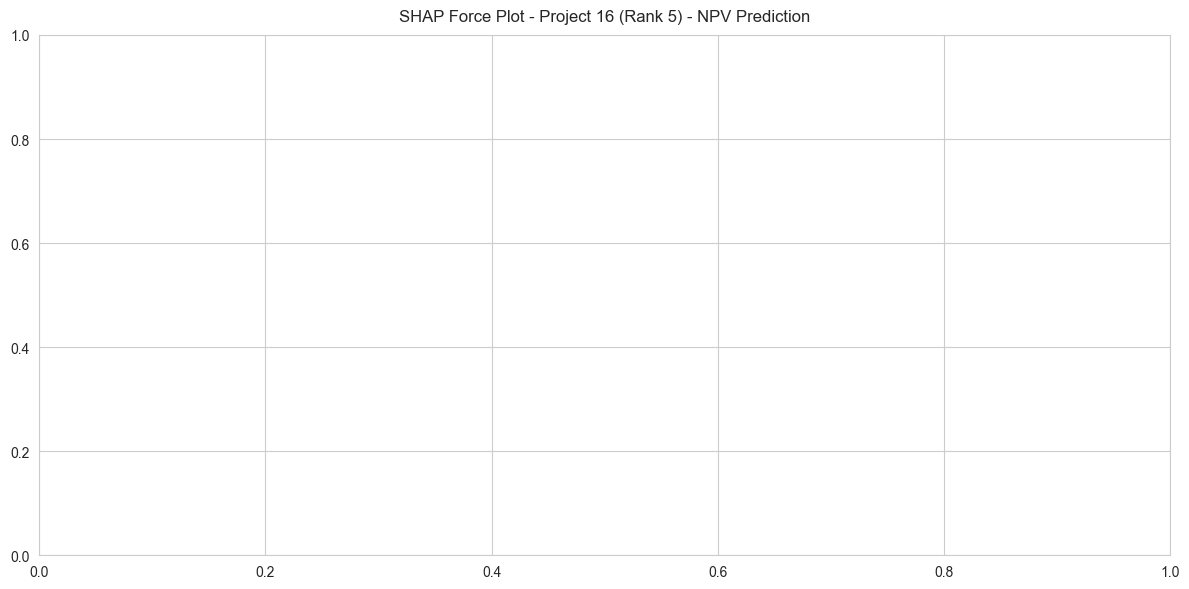

✓ Saved: shap_force_regression_rank_5.png


In [ ]:
# SHAP Force Plot for Top 5 Projects (Regression)
top_5_indices = df_ranked.head(5).index.tolist()

for i, idx in enumerate(top_5_indices, 1):
    fig, ax = plt.subplots(figsize=(14, 3))
    expected_val = explainer_reg.expected_value
    if hasattr(expected_val, "__len__"):
        expected_val = expected_val[0]
    shap.plots._waterfall.waterfall_legacy(
        expected_val,
        shap_values_reg[idx],
        X_processed[idx],
        feature_names=feature_names_reg
    )
    project_id = df_ranked.iloc[idx]['Project_ID']
    plt.title(f'SHAP Force Plot - Project {project_id} (Rank {i}) - NPV Prediction', fontsize=12, pad=10)
    plt.tight_layout()

In [ ]:
# Create SHAP explainer for classification model
print("\nCreating SHAP explainer for Classification model...")
clf_model_final = rf_clf_pipeline.named_steps['classifier']
explainer_clf = shap.TreeExplainer(clf_model_final)
shap_values_clf = explainer_clf.shap_values(X_processed)

print("✓ SHAP explainer created for Classification")
print(f"SHAP values shape (class 0): {shap_values_clf[0].shape}")
print(f"SHAP values shape (class 1): {shap_values_clf[1].shape}")


Creating SHAP explainer for Classification model...
✓ SHAP explainer created for Classification
SHAP values shape (class 0): (16, 2)
SHAP values shape (class 1): (16, 2)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

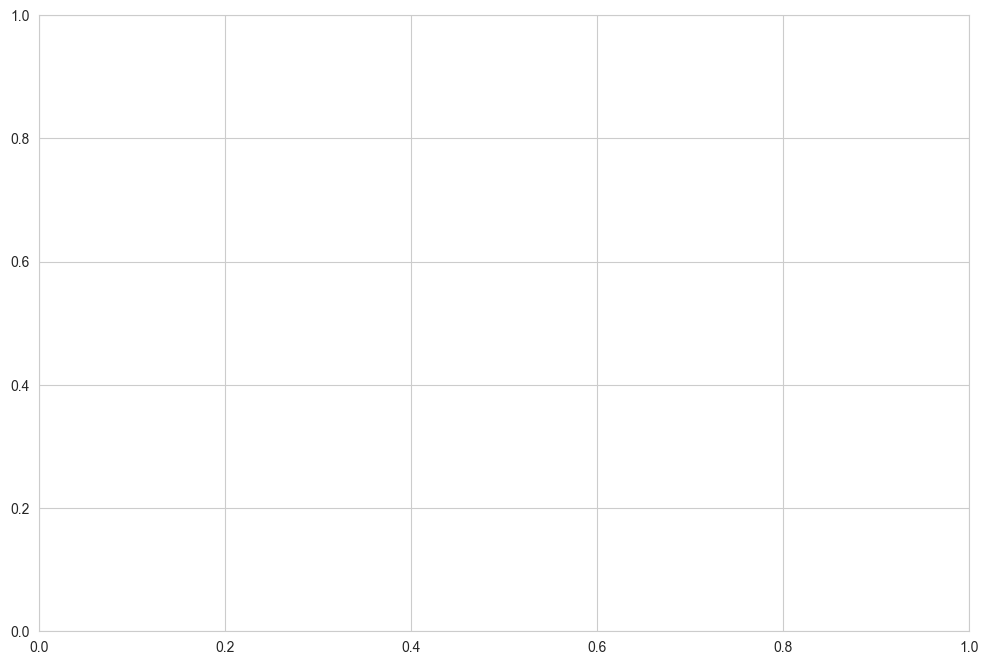

In [ ]:
# SHAP Summary Plot for Classification (Success class)
fig, ax = plt.subplots(figsize=(12, 8))
# Ensure feature names and processed data match the classifier's fitted preprocessor
feature_names_clf = numeric_features + list(
    rf_clf_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_features)
)

X_processed_clf = rf_clf_pipeline.named_steps['preprocessor'].transform(X)

# Ensure processed data is a DataFrame with matching column names, then plot
X_processed_clf_df = pd.DataFrame(X_processed_clf, columns=feature_names_clf, index=X.index)
sv = np.array(shap_values_clf[1])

# If needed, transpose to match (n_samples, n_features)
if sv.shape != X_processed_clf_df.shape and sv.shape[::-1] == X_processed_clf_df.shape:
    sv = sv.T

shap.summary_plot(sv, X_processed_clf_df, feature_names=feature_names_clf,
                  plot_type='bar', max_display=15, show=False)
plt.title('SHAP Summary Plot - Success Probability Prediction (Top 15 Features)', fontsize=14, pad=20)
plt.tight_layout()

In [ ]:
# SHAP Force Plot for Top 5 Projects (Classification - Success Probability)
for i, idx in enumerate(top_5_indices, 1):
    fig, ax = plt.subplots(figsize=(14, 3))
    shap.plots._waterfall.waterfall_legacy(
        explainer_clf.expected_value[1],  # [1] for Success class
        shap_values_clf[1][idx],  # [1] for Success class
        X_processed[idx],
        feature_names=feature_names_reg
    )
    project_id = df_ranked.iloc[idx]['Project_ID']
    plt.title(f'SHAP Force Plot - Project {project_id} (Rank {i}) - Success Probability', fontsize=12, pad=10)
    plt.tight_layout()

In [ ]:
# SHAP Dependence Plots for Key Features (Regression)
key_features_for_dependence = ['Investment_Cost', 'Historical_ROI', 'Market_Growth', 'Risk_Encoded']
key_feature_indices = [feature_names_reg.index(feat) for feat in key_features_for_dependence if feat in feature_names_reg]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax_idx, feat_idx in enumerate(key_feature_indices):
    shap.dependence_plot(feat_idx, shap_values_reg, X_processed, 
                         feature_names=feature_names_reg, ax=axes[ax_idx], show=False)

plt.suptitle('SHAP Dependence Plots - NPV Prediction (Key Features)', fontsize=14, y=1.00)
plt.tight_layout()

In [ ]:
# SHAP Dependence Plots for Key Features (Classification)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax_idx, feat_idx in enumerate(key_feature_indices):
    shap.dependence_plot(feat_idx, shap_values_clf[1], X_processed,  # [1] for Success class
                         feature_names=feature_names_reg, ax=axes[ax_idx], show=False)

plt.suptitle('SHAP Dependence Plots - Success Probability (Key Features)', fontsize=14, y=1.00)
plt.tight_layout()

## PHASE 11: Executive Summary & Key Insights

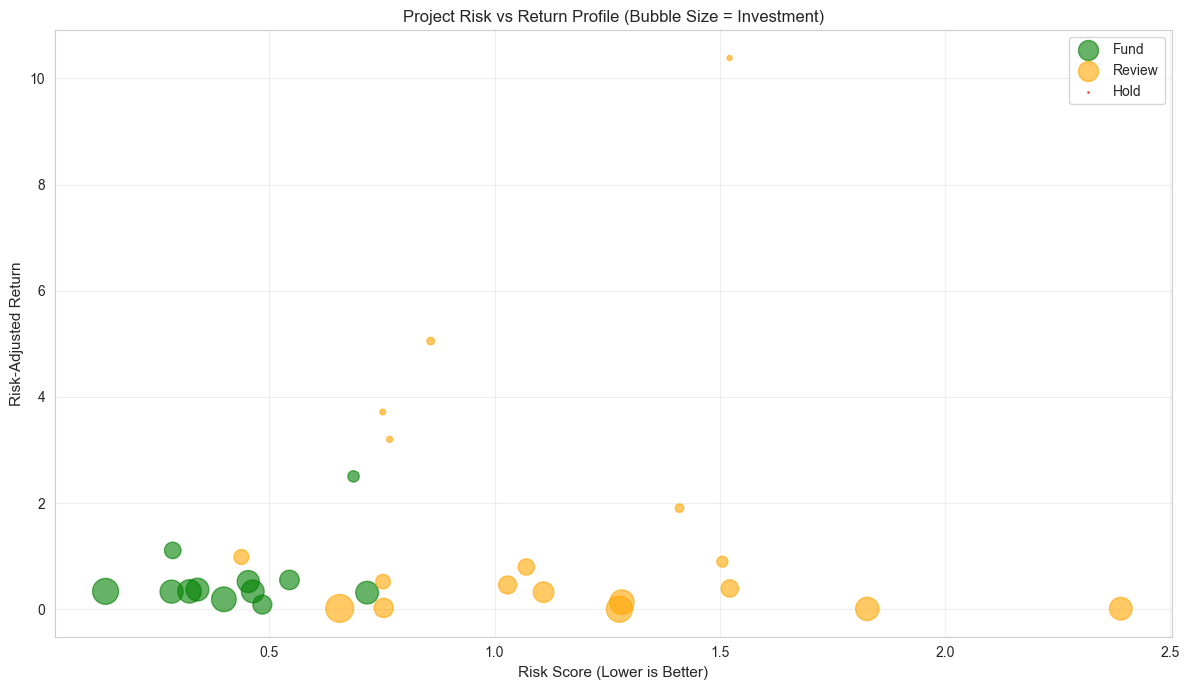

✓ Saved: risk_vs_return.png


In [ ]:
# Create visualization: Risk vs Return Scatter
fig, ax = plt.subplots(figsize=(12, 7))

colors = {'Fund': 'green', 'Review': 'orange', 'Hold': 'red'}
for rec, color in colors.items():
    mask = df_ranked['Recommendation'] == rec
    subset = df_ranked[mask]
    ax.scatter(subset['Risk_Score'], subset['Risk_Adjusted_Return'], 
              s=subset['Investment_Cost']/10000, alpha=0.6, label=rec, color=color)

ax.set_xlabel('Risk Score (Lower is Better)', fontsize=11)
ax.set_ylabel('Risk-Adjusted Return', fontsize=11)
ax.set_title('Project Risk vs Return Profile (Bubble Size = Investment)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## 📊 Finance Executive Review - Essential Columns for Validation

**These columns allow a finance executive to independently verify that each project's FUND/REVIEW/REJECT classification is correct.**

## PHASE 12: Spot checks

In [ ]:
def validate_project_recommendation(project_id):
    """
    Validates all logic conditions for a project's recommendation classification.
    Takes project_id as input and prints a detailed validation table.
    """
    # Get project data
    proj = df_processed[df_processed['Project_ID'] == project_id]
    
    if proj.empty:
        print(f"❌ Project {project_id} not found in dataset")
        return
    
    proj = proj.iloc[0]
    
    # Define all conditions with thresholds
    conditions = [
        {
            'name': '1. NPV > 0?',
            'threshold': '> 0',
            'value': proj['NPV'],
            'check': proj['NPV'] > 0,
            'category': 'FUND'
        },
        {
            'name': '2. Expected_Value > 0?',
            'threshold': '> 0',
            'value': proj['Expected_Value'],
            'check': proj['Expected_Value'] > 0,
            'category': 'FUND'
        },
        {
            'name': '3. Success_Probability >= 60%?',
            'threshold': '>= 0.60',
            'value': proj['Predicted_Success_Probability'],
            'check': proj['Predicted_Success_Probability'] >= 0.60,
            'category': 'FUND'
        },
        {
            'name': '4. Risk_Score <= 4?',
            'threshold': '<= 4.00',
            'value': proj['Risk_Score'],
            'check': proj['Risk_Score'] <= 4,
            'category': 'FUND'
        }
    ]
    
    # Check REJECT conditions
    reject_conditions = [
        {
            'name': 'REJECT Check: Expected_Value < 0?',
            'threshold': '< 0',
            'value': proj['Expected_Value'],
            'check': proj['Expected_Value'] < 0,
            'category': 'REJECT'
        },
        {
            'name': 'REJECT Check: NPV < 0?',
            'threshold': '< 0',
            'value': proj['NPV'],
            'check': proj['NPV'] < 0,
            'category': 'REJECT'
        }
    ]
    
    # Build output table
    print("\n" + "="*160)
    print(f"PROJECT RECOMMENDATION VALIDATION - Project {int(proj['Project_ID'])} ({proj['Department']})")
    print("="*160)
    
    print(f"\nCurrent Classification: {proj['Recommendation']} | Rank: {int(df_ranked[df_ranked['Project_ID']==project_id]['Rank'].values[0])}")
    
    # FUND Criteria Table
    print("\n" + "-"*160)
    print("FUND CRITERIA (ALL 4 must be TRUE to classify as FUND):")
    print("-"*160)
    
    validation_data = []
    for cond in conditions:
        status = "✓ PASS" if cond['check'] else "✗ FAIL"
        validation_data.append({
            'Condition': cond['name'],
            'Threshold': cond['threshold'],
            'Project Value': f"{cond['value']:,.2f}" if isinstance(cond['value'], (int, float)) else str(cond['value']),
            'Result': status
        })
    
    val_df = pd.DataFrame(validation_data)
    print(val_df.to_string(index=False))
    
    # Calculate FUND result
    fund_passes = sum([c['check'] for c in conditions])
    all_pass = all([c['check'] for c in conditions])
    
    print(f"\n  → {fund_passes}/4 FUND conditions passed: {'✓ QUALIFIES FOR FUND' if all_pass else '✗ DOES NOT QUALIFY FOR FUND'}")
    
    # REJECT Criteria Table
    print("\n" + "-"*160)
    print("REJECT CRITERIA (At least 1 must be TRUE to classify as REJECT):")
    print("-"*160)
    
    reject_data = []
    for cond in reject_conditions:
        status = "✓ YES" if cond['check'] else "✗ NO"
        reject_data.append({
            'Condition': cond['name'],
            'Threshold': cond['threshold'],
            'Project Value': f"{cond['value']:,.2f}",
            'Result': status
        })
    
    reject_df = pd.DataFrame(reject_data)
    print(reject_df.to_string(index=False))
    
    reject_any = any([c['check'] for c in reject_conditions])
    print(f"\n  → At least 1 REJECT condition met: {'✓ YES - SHOULD BE REJECT' if reject_any else '✗ NO - NOT REJECT'}")
    
    # Final Decision Logic
    print("\n" + "="*160)
    print("DECISION LOGIC:")
    print("="*160)
    print("""
    IF (all 4 FUND conditions TRUE) → FUND
    ELSE IF (any REJECT condition TRUE) → REJECT
    ELSE → REVIEW
    """)
    
    print("\nDECISION TREE FOR THIS PROJECT:")
    print(f"  1. All FUND conditions TRUE? {all_pass} → {all_pass and 'FUND' or 'Continue'}")
    print(f"  2. Any REJECT condition TRUE? {reject_any} → {reject_any and 'REJECT' or 'Continue'}")
    print(f"  3. Default → REVIEW")
    
    print("\n" + "="*160)
    print(f"FINAL RESULT: Project {int(proj['Project_ID'])} is classified as '{proj['Recommendation']}'")
    print("="*160)
    
    # Show why it failed FUND (if applicable)
    if not all_pass and not reject_any:
        print(f"\n⚠️ WHY NOT FUND? Reason(s) for failure:")
        for cond in conditions:
            if not cond['check']:
                shortfall = "N/A"
                if cond['name'] == '3. Success_Probability >= 60%?':
                    shortfall = f" (Shortfall: {(0.60 - cond['value'])*100:.2f}%)"
                print(f"   ✗ {cond['name']} - Value {cond['value']:.4f} vs Threshold {cond['threshold']}{shortfall}")

# Example usage
validate_project_recommendation(3)


PROJECT RECOMMENDATION VALIDATION - Project 3 (Finance)

Current Classification: Fund | Rank: 2

----------------------------------------------------------------------------------------------------------------------------------------------------------------
FUND CRITERIA (ALL 4 must be TRUE to classify as FUND):
----------------------------------------------------------------------------------------------------------------------------------------------------------------
                     Condition Threshold Project Value Result
                   1. NPV > 0?       > 0  2,121,151.62 ✓ PASS
        2. Expected_Value > 0?       > 0  1,311,784.52 ✓ PASS
3. Success_Probability >= 60%?   >= 0.60          0.85 ✓ PASS
           4. Risk_Score <= 4?   <= 4.00          0.45 ✓ PASS

  → 4/4 FUND conditions passed: ✓ QUALIFIES FOR FUND

---------------------------------------------------------------------------------------------------------------------------------------------------------------